In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error)

# Деревья
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

# Ансамбли
from sklearn.ensemble import (BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor, StackingRegressor)

# Линейные (для стекинга как финальный estimator)
from sklearn.linear_model import Ridge

# Бустинг
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor 

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [12]:
df = pd.read_csv('cars_end.csv')
print(df.shape)
df.head()

(38491, 48)


,manufacturer_name,transmission,odometer_value,year_produced,engine_has_gas,engine_capacity,has_warranty,state,drivetrain,price_usd,...,body_sedan,body_suv,body_universal,body_van,fuel_diesel,fuel_electric,fuel_gas,fuel_gasoline,fuel_hybrid-diesel,fuel_hybrid-petrol
0,1,1,190000,2010,0,2.5,0,1,2,10900.00,...,0,0,1,0,0,0,0,1,0,0
1,1,1,290000,2002,0,3.0,0,1,2,5000.00,...,0,0,1,0,0,0,0,1,0,0
2,1,1,402000,2001,0,2.5,0,1,2,2800.00,...,0,1,0,0,0,0,0,1,0,0
3,1,0,10000,1999,0,3.0,0,1,2,9999.00,...,1,0,0,0,0,0,0,1,0,0
4,1,1,280000,2001,0,2.5,0,1,2,2134.11,...,0,0,1,0,0,0,0,1,0,0


In [13]:


TARGET = 'price_usd'

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Способ 1: Hold-out (train / val / test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Способ 2: K-Fold (будем использовать при подборе гиперпараметров)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print(f"K-Fold: {kf.n_splits} folds")

Train: (26943, 47), Val: (5774, 47), Test: (5774, 47)
K-Fold: 5 folds


In [14]:
def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    res = {}
    for split, X, y in [('train', X_tr, y_tr), ('test', X_te, y_te)]:
        pred = model.predict(X)
        res[split] = {
            'MAE':  mean_absolute_error(y, pred),
            'RMSE': np.sqrt(mean_squared_error(y, pred)),
            'MAPE': mean_absolute_percentage_error(y, pred),
            'R2':   r2_score(y, pred),
        }
    print(f"{name:35s}  Train R²={res['train']['R2']:.4f}  Test R²={res['test']['R2']:.4f}")
    return model, res

all_results = {}

## 3.1 DecisionTreeRegressor

In [15]:
dt_base = DecisionTreeRegressor(random_state=42)
_, res = eval_model('DT (base)', dt_base, X_train, y_train, X_test, y_test)
all_results['DT (base)'] = res

# Подбор гиперпараметров через GridSearchCV + KFold
param_grid = {
    'max_depth':        [5, 10, 15, None],
    'min_samples_split': [2, 10, 50],
    'min_samples_leaf':  [1, 5, 20],
}
gs = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid,
                  cv=kf, scoring='r2', n_jobs=-1)
gs.fit(X_train, y_train)
print("Best params:", gs.best_params_)

dt_best = gs.best_estimator_
_, res = eval_model('DT (GridSearch)', dt_best, X_train, y_train, X_test, y_test)
all_results['DT (GridSearch)'] = res

DT (base)                            Train R²=0.9993  Test R²=0.8034
Best params: {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 50}
DT (GridSearch)                      Train R²=0.9055  Test R²=0.8738


## 4. Визуализация дерева решений

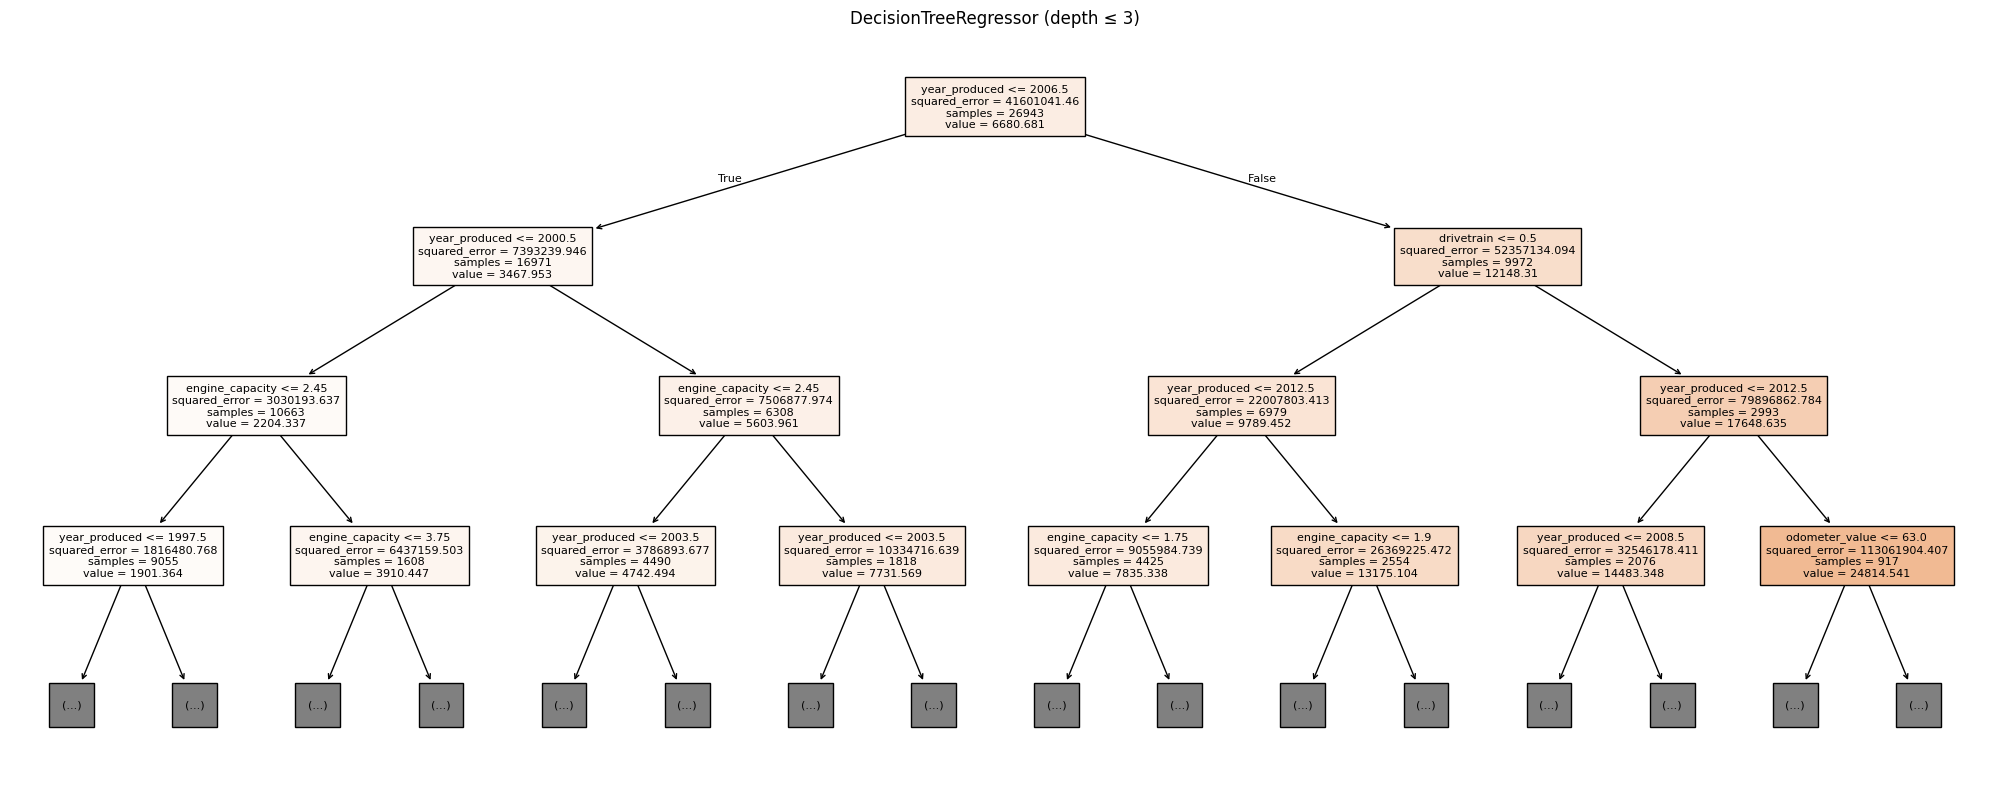

|--- year_produced <= 2006.50
|   |--- year_produced <= 2000.50
|   |   |--- engine_capacity <= 2.45
|   |   |   |--- year_produced <= 1997.50
|   |   |   |   |--- engine_capacity <= 1.85
|   |   |   |   |   |--- truncated branch of depth 11
|   |   |   |   |--- engine_capacity >  1.85
|   |   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- year_produced >  1997.50
|   |   |   |   |--- manufacturer_name <= 1.50
|   |   |   |   |   |--- truncated branch of depth 11
|   |   |   |   |--- manufacturer_name >  1.50
|   |   |   |   |   |--- truncated branch of depth 8
|   |   |--- engine_capacity >  2.45
|   |   |   |--- engine_capacity <= 3.75
|   |   |   |   |--- year_produced <= 1996.50
|   |   |   |   |   |--- truncated branch of depth 11
|   |   |   |   |--- year_produced >  1996.50
|   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |--- engine_capacity >  3.75
|   |   |   |   |--- odometer_value <= 247500.00
|   |   |   |   |   |--- value: [8392.00]
|   | 

In [16]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt_best, max_depth=3, feature_names=X_train.columns,
          filled=True, ax=ax, fontsize=8)
plt.title('DecisionTreeRegressor (depth ≤ 3)')
plt.tight_layout()
plt.show()

print(export_text(dt_best, feature_names=list(X_train.columns), max_depth=4))

## 3.2 Ансамбли sklearn

In [17]:
sklearn_ensembles = [
    ('Bagging',          BaggingRegressor(n_estimators=50, random_state=42, n_jobs=-1)),
    ('RandomForest',     RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('GradientBoosting', GradientBoostingRegressor(n_estimators=200, random_state=42)),
    ('AdaBoost',         AdaBoostRegressor(n_estimators=200, random_state=42)),
    ('Stacking',         StackingRegressor(
        estimators=[
            ('rf',  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
            ('gbr', GradientBoostingRegressor(n_estimators=100, random_state=42)),
        ],
        final_estimator=Ridge(),
        cv=5, n_jobs=-1,
    )),
]

for name, model in sklearn_ensembles:
    _, res = eval_model(name, model, X_train, y_train, X_test, y_test)
    all_results[name] = res

Bagging                              Train R²=0.9852  Test R²=0.9020
RandomForest                         Train R²=0.9860  Test R²=0.9034
GradientBoosting                     Train R²=0.9092  Test R²=0.8974
AdaBoost                             Train R²=-0.0442  Test R²=-0.1109
Stacking                             Train R²=0.9694  Test R²=0.9051


In [18]:
param_dist = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}
rs = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist, n_iter=20, cv=kf, scoring='r2',
    n_jobs=-1, random_state=42, verbose=0,
)
rs.fit(X_train, y_train)
print("Best params:", rs.best_params_)

rf_best = rs.best_estimator_
_, res = eval_model('RandomForest (RandomizedSearch)', rf_best, X_train, y_train, X_test, y_test)
all_results['RandomForest (RandomizedSearch)'] = res

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 20}
RandomForest (RandomizedSearch)      Train R²=0.9843  Test R²=0.9045


## 3.3 Градиентный бустинг: CatBoost / XGBoost / LightGBM

In [20]:
boost_models = [
    ('CatBoost', CatBoostRegressor(iterations=500, random_state=42, verbose=0)),
    ('XGBoost',  XGBRegressor(n_estimators=500, random_state=42, n_jobs=-1, verbosity=0)),
    ('LightGBM', LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1, verbose=-1)),
]

for name, model in boost_models:
    _, res = eval_model(name, model, X_train, y_train, X_test, y_test)
    all_results[name] = res

# Подбор гиперпараметров LightGBM через Optuna
def lgbm_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 150),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    }
    scores = cross_val_score(LGBMRegressor(**params), X_train, y_train,
                             cv=kf, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(lgbm_objective, n_trials=50, show_progress_bar=True)
print("Best params:", study.best_params)

lgbm_best = LGBMRegressor(**study.best_params, random_state=42, n_jobs=-1, verbose=-1)
_, res = eval_model('LightGBM (Optuna)', lgbm_best, X_train, y_train, X_test, y_test)
all_results['LightGBM (Optuna)'] = res

CatBoost                             Train R²=0.9430  Test R²=0.9084
XGBoost                              Train R²=0.9889  Test R²=0.9019
LightGBM                             Train R²=0.9614  Test R²=0.9081


Best trial: 47. Best value: 0.908949: 100%|██████████| 50/50 [25:12<00:00, 30.24s/it] 


Best params: {'n_estimators': 607, 'max_depth': 9, 'learning_rate': 0.022459847562378392, 'num_leaves': 69, 'subsample': 0.6936766298540248, 'colsample_bytree': 0.7349388608443617}
LightGBM (Optuna)                    Train R²=0.9485  Test R²=0.9097


## 5–6. Таблицы результатов

In [21]:
# Таблица 1: Train / Test метрики всех моделей
rows = []
for name, res in all_results.items():
    rows.append({
        'Алгоритм':   name,
        'Train MAE':  res['train']['MAE'],  'Train RMSE': res['train']['RMSE'],
        'Train MAPE': res['train']['MAPE'], 'Train R2':   res['train']['R2'],
        'Test MAE':   res['test']['MAE'],   'Test RMSE':  res['test']['RMSE'],
        'Test MAPE':  res['test']['MAPE'],  'Test R2':    res['test']['R2'],
    })

table1 = pd.DataFrame(rows).set_index('Алгоритм').round(4)
display(table1.style.background_gradient(subset=['Test R2'], cmap='RdYlGn'))

# Таблица 2: hold-out vs k-fold для ключевых моделей
key_models = {
    'RandomForest':      RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting':  GradientBoostingRegressor(n_estimators=200, random_state=42),
    'LightGBM':          LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1, verbose=-1),
}

rows2 = []
for name, model in key_models.items():
    model.fit(X_train, y_train)
    pred_test = model.predict(X_test)
    ho_r2  = r2_score(y_test, pred_test)
    ho_mae = mean_absolute_error(y_test, pred_test)
    cv_r2  = cross_val_score(model, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)
    rows2.append({
        'Алгоритм':       name,
        'HO R2':          round(ho_r2, 4),
        'HO MAE':         round(ho_mae, 2),
        'KFold R2 mean':  round(cv_r2.mean(), 4),
        'KFold R2 std':   round(cv_r2.std(), 4),
    })

table2 = pd.DataFrame(rows2).set_index('Алгоритм')
display(table2)

,Train MAE,Train RMSE,Train MAPE,Train R2,Test MAE,Test RMSE,Test MAPE,Test R2
Алгоритм,,,,,,,,
DT (base),11.426000,165.418700,0.000500,0.999300,1652.706200,2804.784700,0.605800,0.803400
DT (GridSearch),1196.166400,1983.010500,0.494300,0.905500,1362.076400,2247.221600,0.548900,0.873800
Bagging,466.577300,784.022700,0.209300,0.985200,1196.797700,1979.812100,0.451500,0.902000
RandomForest,456.985000,762.944500,0.229600,0.986000,1186.137000,1965.630900,0.468200,0.903400
GradientBoosting,1246.168900,1943.079100,0.624000,0.909200,1262.231000,2025.741500,0.386500,0.897400
AdaBoost,6149.999200,6590.933300,4.370000,-0.044200,6231.643900,6666.790800,4.938800,-0.110900
Stacking,704.332600,1127.937100,0.325900,0.969400,1186.210600,1948.538300,0.364500,0.905100
RandomForest (RandomizedSearch),523.475500,808.275300,0.278000,0.984300,1183.310300,1955.022800,0.472200,0.904500
CatBoost,1039.147800,1540.262800,0.514600,0.943000,1171.639100,1914.288700,0.317900,0.908400


,HO R2,HO MAE,KFold R2 mean,KFold R2 std
Алгоритм,,,,
RandomForest,0.9034,1186.14,0.8981,0.0015
GradientBoosting,0.8974,1262.23,0.8956,0.0021
LightGBM,0.9081,1158.92,0.9056,0.0036


## 7. Вывод

В ходе лабораторной работы были обучены и сравнены 11 моделей регрессии на датасете автомобилей (38 491 объектов, 47 признаков, целевая переменная — `price_usd`).

**Лучшая модель по Test R²:** LightGBM (Optuna) — **R² = 0.9093**. Незначительно уступают CatBoost (0.9084) и LightGBM base (0.9081), что говорит о том, что подбор гиперпараметров через Optuna дал минимальный прирост на данном датасете.

**Лучшая модель по Test MAE:** LightGBM — **MAE = 1158.92$**, что означает среднюю ошибку предсказания цены около 1160 долларов.

**Hold-out vs K-Fold:** Расхождение между методами валидации не превышает 0.003 по R² для всех ключевых моделей (RF: 0.9034 / 0.8981, GBR: 0.8974 / 0.8956, LightGBM: 0.9081 / 0.9056). Низкое стандартное отклонение KFold (0.0015–0.0036) подтверждает стабильность моделей — оценки не зависят от конкретного разбиения данных.

**Интерпретация правил дерева:** Решающее дерево без ограничений (DT base) показало Train R² = 0.9993 при Test R² = 0.8034 — явное переобучение. После подбора гиперпараметров (GridSearch) модель стала обобщать лучше (Test R² = 0.8738), пожертвовав точностью на обучении. Ключевые признаки в корне дерева — `year_produced` и `odometer_value`, что соответствует интуиции: год выпуска и пробег сильнее всего влияют на цену автомобиля.

**Аномалия AdaBoost:** Модель показала отрицательный R² (−0.11) на тесте. Причина — AdaBoost чувствителен к выбросам: он итеративно усиливает вес неправильно предсказанных объектов, а датасет содержит автомобили с нетипично низкой ценой (< 500$), что дестабилизирует обучение.

**Высокий MAPE:** Все модели показали MAPE > 0.31, что объясняется присутствием дешёвых автомобилей в датасете — для них даже небольшая абсолютная ошибка даёт большую относительную. По MAE и R² качество моделей хорошее.